In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_generator = datagen.flow_from_directory("archive/Agricultural-crops/training",target_size=(64,64),class_mode='categorical')

Found 829 images belonging to 30 classes.


In [5]:
test_generator = datagen.flow_from_directory("archive/Agricultural-crops/testing",target_size=(64,64),class_mode='categorical')

Found 831 images belonging to 30 classes.


In [6]:
train_generator

In [7]:
data,label = next(train_generator)
data.shape

(32, 64, 64, 3)

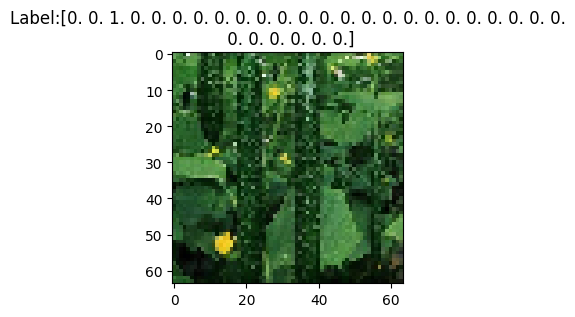

In [8]:
plt.figure(figsize=(3,3))
plt.imshow(data[2])  #from 32 images take first image
plt.title(f"Label:{label[2]}")   # take label of first image& show it as title of image
plt.show()

In [9]:
# cnn = tf.keras.models.Sequential()
# cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu",input_shape=[224,224,3]))
# cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))

# # model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
# # model.add(MaxPooling2D(pool_size=(2,2)))

# cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu"))
# cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))

# cnn.add(tf.keras.layers.Flatten())

# cnn.add(tf.keras.layers.Dense(units=128,activation="relu"))
# cnn.add(tf.keras.layers.Dense(units=1,activation="softmax"))   #output layers

In [10]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu",input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))
cnn.add(tf.keras.layers.Conv2D(filters = 32,kernel_size=3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size = 2,strides=2))
cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=128,activation="relu"))
# cnn.add(tf.keras.layers.Dense(units=1,activation="sigmoid"))   #output layers
cnn.add(tf.keras.layers.Dense(30, activation='softmax'))


C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.compile(optimizer = "adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [12]:
# from tensorflow.keras.optimizers import Adam

In [13]:
# cnn.compile(optimizer="adam",
#             loss="categorical_crossentropy",
#             metrics=["accuracy"])
# 🔹 Compile Model
# cnn.compile(
#     optimizer=Adam(learning_rate=0.001),
#     loss='sparse_categorical_crossentropy',  # For integer labels (0–29)
#     metrics=['accuracy']
# )

In [14]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           3,870 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 816,958 (3.12 MB)

 Trainable params: 816,958 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# result = cnn.fit(x = train_generator,epochs=1)
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',   # ✅ CHANGE THIS
    metrics=['accuracy']
)

In [29]:
result = cnn.fit(x = train_generator,epochs=10)


Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.6562 - loss: 1.2748
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.7636 - loss: 0.9352
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.8384 - loss: 0.6600
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.8914 - loss: 0.5067
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.9469 - loss: 0.2744
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.9674 - loss: 0.1819
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.9928 - loss: 0.0913
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.9976 - loss: 0.0476
Epoch 9/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.9988 - loss: 0.0268
Epoch 10/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 1.0000 - loss: 0.0193


In [17]:
cnn.evaluate(test_generator)

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.6570 - loss: 1.3176


[1.317586064338684, 0.6570397019386292]

In [18]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Load image
new_image = load_img('archive/Agricultural-crops/Single Prediction/jwari1.jpeg',target_size=(64, 64))

# Convert to array
new_image = img_to_array(new_image)

# Rescale if you used rescale=1./255 during training
new_image = new_image / 255.0

# Add batch dimension
new_image = np.expand_dims(new_image, axis=0)
# "C:\Users\Dipak\Desktop\Deep Learning Project\archive\Agricultural-crops\Single Prediction\jwari1.jpeg"


In [19]:
result = cnn.predict(new_image)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
[[2.0952413e-03 4.0128283e-02 1.0507149e-03 3.0324787e-02 1.6688598e-04
  1.4563991e-03 3.9278056e-02 5.0700922e-03 2.7999594e-03 2.3161615e-03
  1.0167381e-02 6.7048930e-03 4.5626923e-02 7.2112791e-02 4.2360574e-02
  2.8933669e-03 5.4729176e-01 4.0004226e-05 2.8134827e-04 3.6202364e-03
  1.2671163e-03 1.1823154e-02 4.3431222e-03 4.7226716e-03 1.6543660e-03
  3.5616703e-02 6.3482708e-05 7.3062503e-03 1.3111653e-03 7.6106109e-02]]


In [20]:
predicted_class_index = np.argmax(result)
print("Predicted Index:", predicted_class_index)


Predicted Index: 16


In [21]:
class_indices = train_generator.class_indices
print(class_indices)


{'Cherry': 0, 'Coffee-plant': 1, 'Cucumber': 2, 'Fox_nut(Makhana)': 3, 'Lemon': 4, 'Olive-tree': 5, 'Pearl_millet(bajra)': 6, 'Tobacco-plant': 7, 'almond': 8, 'banana': 9, 'cardamom': 10, 'chilli': 11, 'clove': 12, 'coconut': 13, 'cotton': 14, 'gram': 15, 'jowar': 16, 'jute': 17, 'maize': 18, 'mustard-oil': 19, 'papaya': 20, 'pineapple': 21, 'rice': 22, 'soyabean': 23, 'sugarcane': 24, 'sunflower': 25, 'tea': 26, 'tomato': 27, 'vigna-radiati(Mung)': 28, 'wheat': 29}


In [22]:
class_labels = dict((v,k) for k,v in class_indices.items())

prediction = class_labels[predicted_class_index]
print("Predicted Crop:", prediction)


Predicted Crop: jowar


In [24]:
cnn.save("model.h5")


In [25]:
import json

with open("class_names.json", "w") as f:
    json.dump(train_generator.class_indices, f)


In [27]:
print(cnn.output_shape)


(None, 30)


In [28]:
print(train_generator.class_indices)


{'Cherry': 0, 'Coffee-plant': 1, 'Cucumber': 2, 'Fox_nut(Makhana)': 3, 'Lemon': 4, 'Olive-tree': 5, 'Pearl_millet(bajra)': 6, 'Tobacco-plant': 7, 'almond': 8, 'banana': 9, 'cardamom': 10, 'chilli': 11, 'clove': 12, 'coconut': 13, 'cotton': 14, 'gram': 15, 'jowar': 16, 'jute': 17, 'maize': 18, 'mustard-oil': 19, 'papaya': 20, 'pineapple': 21, 'rice': 22, 'soyabean': 23, 'sugarcane': 24, 'sunflower': 25, 'tea': 26, 'tomato': 27, 'vigna-radiati(Mung)': 28, 'wheat': 29}
